#Description: This program can predict whether the stock      
              price of a company(Dow Jones Industry) will increase or decrease based on the top news headlines.

Installing required libraries

In [5]:
pip install vaderSentiment

In [6]:
#Import the libraries
import pandas as pd
import numpy as np
import re
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer 
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns 
import pickle 

Importing the datasets

In [7]:
#Store the data 
df1= pd.read_csv("Combined_News_DJIA.csv") #Top 25 headlines on the Company
df2= pd.read_csv("upload_DJIA_table.csv") #Historical Stock prices of the Company

In [8]:
#Show the first 3 rows of df1
df1.head(3)

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Georgia Invades South Ossetia - if Russia ge...,b'Al-Qaeda Faces Islamist Backlash',"b'Condoleezza Rice: ""The US would not act to p...",b'This is a busy day: The European Union has ...,"b""Georgia will withdraw 1,000 soldiers from Ir...",b'Why the Pentagon Thinks Attacking Iran is a ...,b'Caucasus in crisis: Georgia invades South Os...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge"""
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Israel and the US behind the Georgian aggres...,"b'""Do not believe TV, neither Russian nor Geor...",b'Riots are still going on in Montreal (Canada...,b'China to overtake US as largest manufacturer',b'War in South Ossetia [PICS]',b'Israeli Physicians Group Condemns State Tort...,b' Russia has just beaten the United States ov...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo..."
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'U.S. troops still in Georgia (did you know t...,b'Why Russias response to Georgia was right',"b'Gorbachev accuses U.S. of making a ""serious ...","b'Russia, Georgia, and NATO: Cold War Two'",b'Remember that adorable 62-year-old who led y...,b'War in Georgia: The Israeli connection',b'All signs point to the US encouraging Georgi...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man..."


In [9]:
#No. of rows and columns in df1
df1.shape

(1989, 27)

In [10]:
#Show first 3 rows of df2
df2.head(3)

,Date,Open,High,Low,Close,Volume,Adj Close
0,2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141
1,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234
2,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688


In [11]:
#no of rows and columns in df2
df2.shape

(1989, 7)

In [12]:
#merge the two datasets according to the date field
merge = df1.merge(df2,left_index=True,right_index=True,)

In [13]:
#Show the merged dataset
merge.head(3)

,Date_x,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top23,Top24,Top25,Date_y,Open,High,Low,Close,Volume,Adj Close
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Indian shoe manufactory - And again in a se...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge""",2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Perhaps *the* question about the Georgia - R...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo...",2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'Christopher King argues that the US and NATO...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man...",2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688


In [42]:
merge1=merge.copy()

Slicing the headlines for preprocessing

In [15]:
#Combine the top news headlines
headlines=[]

for y in range(0, len(merge.index)):
    headlines.append(' '.join(str(x) for x in merge.iloc[y,2:27]))

In [16]:
#Show the combined headlines
headlines


['b"Georgia \'downs two Russian warplanes\' as countries move to brink of war" b\'BREAKING: Musharraf to be impeached.\' b\'Russia Today: Columns of troops roll into South Ossetia; footage from fighting (YouTube)\' b\'Russian tanks are moving towards the capital of South Ossetia, which has reportedly been completely destroyed by Georgian artillery fire\' b"Afghan children raped with \'impunity,\' U.N. official says - this is sick, a three year old was raped and they do nothing" b\'150 Russian tanks have entered South Ossetia whilst Georgia shoots down two Russian jets.\' b"Breaking: Georgia invades South Ossetia, Russia warned it would intervene on SO\'s side" b"The \'enemy combatent\' trials are nothing but a sham: Salim Haman has been sentenced to 5 1/2 years, but will be kept longer anyway just because they feel like it." b\'Georgian troops retreat from S. Osettain capital, presumably leaving several hundred people killed. [VIDEO]\' b\'Did the U.S. Prep Georgia for War with Russia?\

Preprocessing

In [17]:
#removing unnecessary characters
clean_headlines=[]

for i in range (0, len(headlines)):
    clean_headlines.append(re.sub("b[(')]",'',headlines[i])) #remove b'
    clean_headlines[i] = re.sub('b[(")]','',clean_headlines[i]) #remove b"
    clean_headlines[i] = re.sub("\'",'',clean_headlines[i]) #remove \'

In [18]:
clean_headlines1= [re.sub(r'[^a-zA-Z]', ' ', s)for s in clean_headlines]


In [19]:
#Show clean_headlines
clean_headlines1

['Georgia downs two Russian warplanes as countries move to brink of war  BREAKING  Musharraf to be impeached  Russia Today  Columns of troops roll into South Ossetia  footage from fighting  YouTube  Russian tanks are moving towards the capital of South Ossetia  which has reportedly been completely destroyed by Georgian artillery fire Afghan children raped with impunity  U N  official says   this is sick  a three year old was raped and they do nothing      Russian tanks have entered South Ossetia whilst Georgia shoots down two Russian jets  Breaking  Georgia invades South Ossetia  Russia warned it would intervene on SOs side  The enemy combatent trials are nothing but a sham  Salim Haman has been sentenced to       years  but will be kept longer anyway just because they feel like it   Georgian troops retreat from S  Osettain capital  presumably leaving several hundred people killed   VIDEO  Did the U S  Prep Georgia for War with Russia  Rice Gives Green Light for Israel to Attack Iran  

In [20]:
merge['Combined_news']=clean_headlines1

In [21]:
merge.head(3)

,Date_x,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top24,Top25,Date_y,Open,High,Low,Close,Volume,Adj Close,Combined_news
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,b'Visitors Suffering from Mental Illnesses Ban...,"b""No Help for Mexico's Kidnapping Surge""",2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141,Georgia downs two Russian warplanes as countri...
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,b'Russia is so much better at war',"b""So this is what it's come to: trading sex fo...",2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234,Why wont America and Nato help us If they won...
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,b'America: The New Mexico?',"b""BBC NEWS | Asia-Pacific | Extinction 'by man...",2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688,Remember that adorable year old who sang at ...


Finding Sentiment of the news headlines

In [22]:
#Creating a function to get the Subjectivity and Polarity
def sub(text):
    return TextBlob(text).sentiment.subjectivity

def pol(text):
    return TextBlob(text).sentiment.polarity
 

In [23]:
#Creating new columns for subjectivity and polarity
merge['Subjectivity'] = merge['Combined_news'].apply(sub)
merge['Polarity'] = merge['Combined_news'].apply(pol)

In [24]:
merge.head(3)

,Date_x,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Date_y,Open,High,Low,Close,Volume,Adj Close,Combined_news,Subjectivity,Polarity
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,2016-07-01,17924.240234,18002.380859,17916.910156,17949.369141,82160000,17949.369141,Georgia downs two Russian warplanes as countri...,0.267549,-0.048568
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,2016-06-30,17712.759766,17930.609375,17711.800781,17929.990234,133030000,17929.990234,Why wont America and Nato help us If they won...,0.374806,0.109325
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,2016-06-29,17456.019531,17704.509766,17456.019531,17694.679688,106380000,17694.679688,Remember that adorable year old who sang at ...,0.510370,-0.033202


In [25]:
def getSIA(text):
    sia = SentimentIntensityAnalyzer()
    sentiment= sia.polarity_scores(text)
    return sentiment

compound = []
neg=[]
neu=[]
pos=[]
SIA=0

for i in range(0, len(merge['Combined_news'])):
    SIA=getSIA(merge['Combined_news'][i])
    compound.append(SIA['compound'])
    neg.append(SIA['neg'])
    neu.append(SIA['neu'])
    pos.append(SIA['pos'])

In [26]:
merge['Compound'] = compound
merge['Positive'] = pos
merge['Neutral'] = neu
merge['Negative'] = neg

In [27]:
s=['Subjectivity', 'Polarity', 'Compound','Positive','Neutral','Negative']
data= merge[s]   

In [28]:
merge.head(3)

,Date_x,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Close,Volume,Adj Close,Combined_news,Subjectivity,Polarity,Compound,Positive,Neutral,Negative
0,2008-08-08,0,"b""Georgia 'downs two Russian warplanes' as cou...",b'BREAKING: Musharraf to be impeached.',b'Russia Today: Columns of troops roll into So...,b'Russian tanks are moving towards the capital...,"b""Afghan children raped with 'impunity,' U.N. ...",b'150 Russian tanks have entered South Ossetia...,"b""Breaking: Georgia invades South Ossetia, Rus...","b""The 'enemy combatent' trials are nothing but...",...,17949.369141,82160000,17949.369141,Georgia downs two Russian warplanes as countri...,0.267549,-0.048568,-0.9982,0.041,0.724,0.235
1,2008-08-11,1,b'Why wont America and Nato help us? If they w...,b'Bush puts foot down on Georgian conflict',"b""Jewish Georgian minister: Thanks to Israeli ...",b'Georgian army flees in disarray as Russians ...,"b""Olympic opening ceremony fireworks 'faked'""",b'What were the Mossad with fraudulent New Zea...,b'Russia angered by Israeli military sale to G...,b'An American citizen living in S.Ossetia blam...,...,17929.990234,133030000,17929.990234,Why wont America and Nato help us If they won...,0.374806,0.109325,-0.9838,0.089,0.724,0.187
2,2008-08-12,0,b'Remember that adorable 9-year-old who sang a...,"b""Russia 'ends Georgia operation'""","b'""If we had no sexual harassment we would hav...","b""Al-Qa'eda is losing support in Iraq because ...",b'Ceasefire in Georgia: Putin Outmaneuvers the...,b'Why Microsoft and Intel tried to kill the XO...,b'Stratfor: The Russo-Georgian War and the Bal...,"b""I'm Trying to Get a Sense of This Whole Geor...",...,17694.679688,106380000,17694.679688,Remember that adorable year old who sang at ...,0.510370,-0.033202,-0.9679,0.055,0.820,0.125


Creating the ML Model

In [29]:
#create a list of columns to use in the model training
column = ['Open','High','Low','Volume', 'Subjectivity', 'Polarity', 'Compound', 'Positive', 'Neutral', 'Negative', 'Label'] 
df = merge[column]

In [30]:
df

,Open,High,Low,Volume,Subjectivity,Polarity,Compound,Positive,Neutral,Negative,Label
0,17924.240234,18002.380859,17916.910156,82160000,0.267549,-0.048568,-0.9982,0.041,0.724,0.235,0
1,17712.759766,17930.609375,17711.800781,133030000,0.374806,0.109325,-0.9838,0.089,0.724,0.187,1
2,17456.019531,17704.509766,17456.019531,106380000,0.510370,-0.033202,-0.9679,0.055,0.820,0.125,0
3,17190.509766,17409.720703,17190.509766,112190000,0.364021,0.005842,-0.9818,0.066,0.782,0.152,0
4,17355.210938,17355.210938,17063.080078,138740000,0.390095,0.049050,-0.9846,0.106,0.706,0.189,1
...,...,...,...,...,...,...,...,...,...,...,...
1984,11532.070312,11718.280273,11450.889648,159790000,0.352311,-0.014015,-0.9644,0.094,0.758,0.148,0
1985,11632.809570,11633.780273,11453.339844,182550000,0.349330,0.047722,-0.9571,0.103,0.763,0.133,1
1986,11781.700195,11782.349609,11601.519531,173590000,0.417835,0.075882,-0.9979,0.095,0.667,0.239,1
1987,11729.669922,11867.110352,11675.530273,183190000,0.382566,0.011243,-0.9978,0.062,0.729,0.209,1


In [31]:
#feature dataset
X = df
X = np.array(X.drop(['Label'], axis=1))

#target dataset
y = np.array(df['Label'])

In [32]:
#spliting the data into train and test
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 0) #train - 80%, test - 20%

In [33]:
#Creating the model
model = LinearDiscriminantAnalysis().fit(x_train, y_train)

In [34]:
#Showing the model predictions
prediction = model.predict(x_test)
prediction

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [35]:
y_test

array([1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,

In [36]:
#Showing the model metrics
f1 = f1_score(y_test,prediction)
print(f"F1 Score: {f1}")

F1 Score: 0.6727688787185354


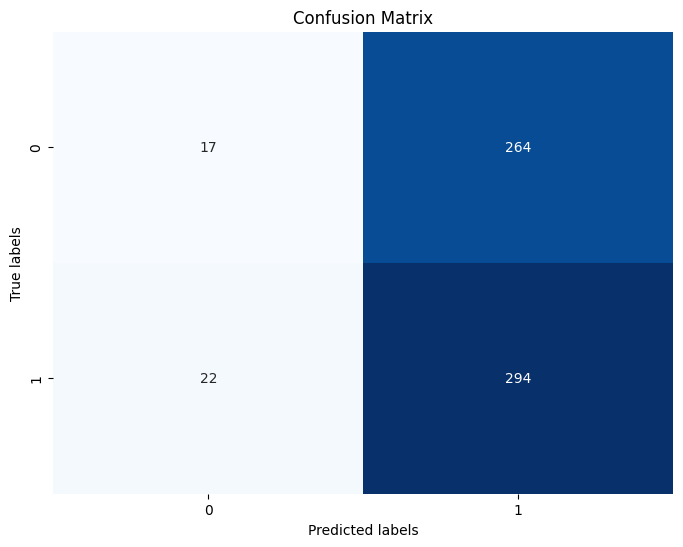

In [37]:
#Corellation matrix showing imbalance between class 0 and class 1
cm = confusion_matrix(y_test, prediction)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [44]:
pickle_out= open("f1.pkl","wb")
pickle.dump(f1,pickle_out) 
pickle_out.close()

pickle_out= open("data.pkl","wb")
pickle.dump(data,pickle_out) 
pickle_out.close()

pickle_out= open("merge.pkl","wb")
pickle.dump(merge1,pickle_out) 
pickle_out.close()